# Faster R-CNN Complete Standalone Pipeline for Kaggle

This notebook contains everything needed to train and evaluate Faster R-CNN on Pascal VOC 2012 dataset.
It's designed to run standalone in Kaggle without external dependencies.

## Features:
- Complete VOC to COCO conversion
- Faster R-CNN training with enhanced logging
- Comprehensive evaluation with COCO metrics
- Visual comparisons of ground truth vs predictions
- Model checkpointing and visualization
- Comparison images testing from comparison_images.json

## 1. Setup and Imports

In [1]:
import os
import sys
import json
import xml.etree.ElementTree as ET
import logging
import random
import time
from datetime import datetime
from pathlib import Path
import shutil

# Data handling
import pandas as pd
import numpy as np
from PIL import Image, ImageDraw, ImageFont

# ML/DL libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms
import torchvision.transforms.functional as F
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display, clear_output

# COCO evaluation
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Configure matplotlib and seaborn
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ All imports successful!
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ===== Shared benchmark_common bootstrap (P0) =====
# Locates the repo root (identified by benchmark_common/protocol.py) and adds
# it to sys.path so the shared evaluation/timing/dataset-conversion module is
# importable. If this notebook was imported standalone (e.g. via Kaggle's
# "Import Notebook" flow, which only pulls in the single .ipynb file, not the
# rest of the repo), benchmark_common won't exist anywhere on disk -- in that
# case this clones the repo (dev branch, where these files live) into
# /kaggle/working (or /content on Colab) and uses that as the repo root.
import sys
import subprocess
from pathlib import Path

_REPO_URL = 'https://github.com/nithin-pulla/object-detection-benchmarking-and-analysis.git'
_REPO_BRANCH = 'dev'  # benchmark_common currently only exists on dev, not main


def _find_repo_root():
    anchor = Path('benchmark_common') / 'protocol.py'
    candidates = [Path.cwd(), *Path.cwd().parents]
    candidates += [
        Path('/kaggle/working/object-detection-benchmarking-and-analysis'),
        Path('/kaggle/working'),
        Path('/content/object-detection-benchmarking-and-analysis'),
        Path('/content'),
    ]
    scanned = list(candidates)
    for c in candidates:
        try:
            scanned += [p for p in c.iterdir() if p.is_dir()]
        except (FileNotFoundError, NotADirectoryError, PermissionError):
            continue
    seen = set()
    for c in scanned:
        try:
            c = c.resolve()
        except OSError:
            continue
        if c in seen:
            continue
        seen.add(c)
        if (c / anchor).exists():
            return c
    return None


def _clone_repo_root():
    if Path('/kaggle/working').exists():
        dest = Path('/kaggle/working/object-detection-benchmarking-and-analysis')
    elif Path('/content').exists():
        dest = Path('/content/object-detection-benchmarking-and-analysis')
    else:
        dest = Path.cwd() / 'object-detection-benchmarking-and-analysis'

    if not (dest / 'benchmark_common' / 'protocol.py').exists():
        print(f"benchmark_common not found on disk -- cloning {_REPO_URL} ({_REPO_BRANCH}) into {dest} ...")
        result = subprocess.run(
            ['git', 'clone', '--depth', '1', '--branch', _REPO_BRANCH, _REPO_URL, str(dest)],
            capture_output=True, text=True
        )
        if result.returncode != 0:
            raise FileNotFoundError(
                f"Could not locate 'benchmark_common/protocol.py' locally, and cloning "
                f"{_REPO_URL} failed:\n{result.stderr}\n"
                f"Clone the repo (branch '{_REPO_BRANCH}') yourself and set sys.path manually, e.g.:\n"
                f"    sys.path.insert(0, '{dest}')"
            )
    return dest


_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is None:
    _REPO_ROOT = _clone_repo_root()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
print(f"benchmark_common resolved from: {_REPO_ROOT}")

from benchmark_common import protocol, seeding, voc_coco, eval_coco, speed_bench, comparison

seeding.set_global_seed(protocol.GLOBAL_SEED)
print(f"Global seed set to {protocol.GLOBAL_SEED} (P0: benchmark_common.seeding)")
print(f"Shared evaluation operating point: conf={protocol.CONF_THRESHOLD}, IoU={protocol.IOU_THRESHOLD}")


benchmark_common not found on disk -- cloning https://github.com/nithin-pulla/object-detection-benchmarking-and-analysis.git (dev) into /kaggle/working/object-detection-benchmarking-and-analysis ...
benchmark_common resolved from: /kaggle/working/object-detection-benchmarking-and-analysis
Global seed set to 42 (P0: benchmark_common.seeding)
Shared evaluation operating point: conf=0.25, IoU=0.5


In [3]:
# Ensure pycocotools is available (Kaggle validation fix). It is not listed
# in requirements.txt and Kaggle's base image doesn't guarantee it -- this
# was already an implicit dependency of the original notebook (COCOeval)
# and is now also required by benchmark_common.eval_coco.
try:
    import pycocotools
    print(f"pycocotools already available: {pycocotools.__file__}")
except ImportError:
    print("pycocotools not found -- installing...")
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pycocotools'], check=True)
    import pycocotools
    print("pycocotools installed")


pycocotools already available: /usr/local/lib/python3.12/dist-packages/pycocotools/__init__.py


In [4]:
# Capture the ACTUAL runtime environment (Kaggle validation fix):
# requirements.txt pins torch==2.7.1 / torchvision==0.22.1, but this
# notebook never runs `pip install -r requirements.txt` -- it imports
# whatever Kaggle's base image already provides. Recording the real
# versions here (rather than forcing a possibly CUDA-incompatible
# reinstall) keeps every run individually traceable/reproducible.
import subprocess as _subprocess


def _git_commit_hash(repo_root):
    try:
        result = _subprocess.run(
            ['git', 'rev-parse', 'HEAD'], cwd=str(repo_root),
            capture_output=True, text=True, check=True
        )
        return result.stdout.strip()
    except Exception:
        return 'unknown'


environment_info = {
    'python_version': sys.version,
    'torch_version': torch.__version__,
    'torchvision_version': torchvision.__version__,
    'cuda_version': torch.version.cuda,
    'cudnn_version': torch.backends.cudnn.version() if torch.cuda.is_available() else None,
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'repo_commit': _git_commit_hash(_REPO_ROOT),
    'repo_branch': _REPO_BRANCH,
    'global_seed': protocol.GLOBAL_SEED,
}

print("Environment info (recorded for reproducibility):")
for _k, _v in environment_info.items():
    print(f"   {_k}: {_v}")


Environment info (recorded for reproducibility):
   python_version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
   torch_version: 2.10.0+cu128
   torchvision_version: 0.25.0+cu128
   cuda_version: 12.8
   cudnn_version: 91002
   gpu_name: Tesla T4
   repo_commit: 45de52d6b28cb43583377691e9f213490dcacd82
   repo_branch: dev
   global_seed: 42


In [5]:
# GPU/CUDA compatibility pre-flight check (Kaggle validation fix): a
# "CUDA error: no kernel image is available for execution on the device"
# during training means the installed torch build's compiled kernels don't
# cover this GPU's compute capability. Catch that here, before burning
# time on data prep/training, with an actionable message instead of a
# traceback three layers deep in torchvision's transform code.
if torch.cuda.is_available():
    _gpu_cap = torch.cuda.get_device_capability(0)
    _gpu_arch = f"sm_{_gpu_cap[0]}{_gpu_cap[1]}"
    _supported_archs = torch.cuda.get_arch_list()
    print(f"GPU: {torch.cuda.get_device_name(0)} (compute capability {_gpu_cap[0]}.{_gpu_cap[1]}, {_gpu_arch})")
    print(f"torch {torch.__version__} was built with kernels for: {_supported_archs}")
    if _gpu_arch not in _supported_archs:
        raise RuntimeError(
            f"This GPU's compute capability ({_gpu_arch}) is not in the set of "
            f"architectures torch {torch.__version__} was compiled for "
            f"({_supported_archs}). Training will fail with 'CUDA error: no "
            f"kernel image is available for execution on the device'.\n"
            f"Fix: in Kaggle's notebook Settings (right sidebar), change the "
            f"Accelerator to a different GPU option -- 'GPU T4 x2' is the most "
            f"broadly supported by Kaggle's stock PyTorch image -- then Factory "
            f"Reset the session and re-run from the top."
        )
else:
    print("WARNING: CUDA not available -- training will run on CPU (slow).")


GPU: Tesla T4 (compute capability 7.5, sm_75)
torch 2.10.0+cu128 was built with kernels for: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## 2. Configuration and Global Variables

In [6]:
# ===== CONFIGURATION - MODIFY THESE PATHS FOR YOUR SETUP =====

# For Kaggle, update these paths to match your Kaggle setup
CONFIG = {
    # Dataset paths (modify for Kaggle)
    'voc_root': '/kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012',  # Kaggle input path
    'output_dir': '/kaggle/working/fasterrcnn_outputs',  # Kaggle working directory
    
    # Training parameters
    'batch_size': 2,
    'num_epochs': 5,
    'learning_rate': 0.005,
    'momentum': 0.9,
    'weight_decay': 0.0005,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 4,
    
    # Evaluation parameters (P0: standardized via benchmark_common.protocol
    # -- must be identical across all three models for the primary comparison)
    'conf_threshold': protocol.CONF_THRESHOLD,
    'nms_threshold': protocol.IOU_THRESHOLD,
    
    # Experiment settings
    'experiment_name': f'fasterrcnn_voc_{datetime.now().strftime("%Y%m%d_%H%M%S")}',
    'save_checkpoints': True,
    'checkpoint_every': 1,  # Save every N epochs
    'save_visualizations': True,
    'run_comparison_images': True
}

# VOC Classes
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(VOC_CLASSES)}
IDX_TO_CLASS = {idx: cls for idx, cls in enumerate(VOC_CLASSES)}

# Create output directories
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/models", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/logs", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/predictions", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/visualizations", exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/data", exist_ok=True)

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print(f"\n📁 Output directory created: {CONFIG['output_dir']}")
print(f"🎯 Experiment name: {CONFIG['experiment_name']}")

Configuration:
  voc_root: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012
  output_dir: /kaggle/working/fasterrcnn_outputs
  batch_size: 2
  num_epochs: 5
  learning_rate: 0.005
  momentum: 0.9
  weight_decay: 0.0005
  device: cuda
  num_workers: 4
  conf_threshold: 0.25
  nms_threshold: 0.5
  experiment_name: fasterrcnn_voc_20260824_184301
  save_checkpoints: True
  checkpoint_every: 1
  save_visualizations: True
  run_comparison_images: True

📁 Output directory created: /kaggle/working/fasterrcnn_outputs
🎯 Experiment name: fasterrcnn_voc_20260824_184301


In [7]:
# Verify the dataset mount path BEFORE the expensive VOC->COCO conversion
# runs (Kaggle validation fix). Kaggle mounts an attached dataset at
# /kaggle/input/<dataset-slug>/..., and <dataset-slug> may not match the
# 'voc2012' this notebook assumes by default.
if not os.path.exists(CONFIG['voc_root']):
    _kaggle_input = Path('/kaggle/input')
    _available = sorted(p.name for p in _kaggle_input.iterdir()) if _kaggle_input.exists() else []
    raise FileNotFoundError(
        f"CONFIG['voc_root'] does not exist: {CONFIG['voc_root']}\n"
        f"Available datasets under /kaggle/input: {_available}\n"
        f"Update CONFIG['voc_root'] above to match the actual mounted path, "
        f"e.g. '/kaggle/input/<actual-slug>/VOCdevkit/VOC2012', then re-run "
        f"from the CONFIGURATION cell."
    )
else:
    print(f"VOC dataset found at: {CONFIG['voc_root']}")


VOC dataset found at: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012


## 3. Enhanced Logging Setup

In [8]:
# Setup comprehensive logging
log_file = f"{CONFIG['output_dir']}/logs/{CONFIG['experiment_name']}.log"

# Create custom logger
logger = logging.getLogger('FasterRCNN_Pipeline')
logger.setLevel(logging.INFO)

# Clear existing handlers
for handler in logger.handlers[:]:
    logger.removeHandler(handler)

# File handler
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.INFO)

# Console handler
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)

# Formatter
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

# Add handlers
logger.addHandler(file_handler)
logger.addHandler(console_handler)

# Training metrics tracking
training_metrics = {
    'start_time': None,
    'end_time': None,
    'epoch_times': [],
    'train_losses': [],
    'learning_rates': [],
    'best_map': 0.0,
    'final_metrics': {},
    'total_parameters': 0,
    'model_size_mb': 0
}

logger.info(f"Starting Faster R-CNN experiment: {CONFIG['experiment_name']}")
logger.info(f"Configuration: {CONFIG}")
logger.info(f"Log file: {log_file}")

print(f"✅ Enhanced logging setup complete")
print(f"📝 Log file: {log_file}")

2026-08-24 18:43:01,615 - FasterRCNN_Pipeline - INFO - Starting Faster R-CNN experiment: fasterrcnn_voc_20260824_184301
2026-08-24 18:43:01,616 - FasterRCNN_Pipeline - INFO - Configuration: {'voc_root': '/kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012', 'output_dir': '/kaggle/working/fasterrcnn_outputs', 'batch_size': 2, 'num_epochs': 5, 'learning_rate': 0.005, 'momentum': 0.9, 'weight_decay': 0.0005, 'device': 'cuda', 'num_workers': 4, 'conf_threshold': 0.25, 'nms_threshold': 0.5, 'experiment_name': 'fasterrcnn_voc_20260824_184301', 'save_checkpoints': True, 'checkpoint_every': 1, 'save_visualizations': True, 'run_comparison_images': True}
2026-08-24 18:43:01,617 - FasterRCNN_Pipeline - INFO - Log file: /kaggle/working/fasterrcnn_outputs/logs/fasterrcnn_voc_20260824_184301.log


✅ Enhanced logging setup complete
📝 Log file: /kaggle/working/fasterrcnn_outputs/logs/fasterrcnn_voc_20260824_184301.log


## 4. VOC to COCO Conversion Functions

In [9]:
# VOC to COCO conversion (P0: shared benchmark_common.voc_coco -- removes the
# duplicate copy of this function previously pasted into both the FasterRCNN
# and SSD300 notebooks).
convert_voc_to_coco = voc_coco.convert_voc_to_coco

print("✅ VOC to COCO conversion (shared benchmark_common.voc_coco) ready")


✅ VOC to COCO conversion (shared benchmark_common.voc_coco) ready


## 5. Dataset and Transform Classes

In [10]:
class Compose(object):
    """Compose transforms that take (image, target) and return (image, target)."""
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target):
        for t in self.transforms:
            image, target = t(image, target)
        return image, target

class ToTensor(object):
    """Convert PIL image to Tensor (leave target untouched)."""
    def __call__(self, image, target):
        return F.to_tensor(image), target

class RandomHorizontalFlip(object):
    """Horizontally flip image & boxes with probability p."""
    def __init__(self, p=0.5):
        self.p = p
    def __call__(self, image, target):
        if random.random() < self.p:
            # flip image
            image = F.hflip(image)
            # flip boxes
            w, _ = image.size
            boxes = target["boxes"].clone()
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]
            target["boxes"] = boxes
        return image, target

def get_transform(train):
    transforms = []
    if train:
        transforms.append(RandomHorizontalFlip(0.5))
    transforms.append(ToTensor())
    return Compose(transforms)

class VOCDataset(torch.utils.data.Dataset):
    """Pascal VOC Dataset for Faster R-CNN"""
    def __init__(self, root, image_set="train", transforms=None):
        self.root = root
        self.transforms = transforms
        # build list of image IDs
        id_file = os.path.join(root, "ImageSets", "Main", f"{image_set}.txt")
        with open(id_file) as f:
            self.ids = [line.strip() for line in f]
        
        logger.info(f"VOC Dataset initialized with {len(self.ids)} images for {image_set} set")
    
    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        # load image
        img_path = os.path.join(self.root, "JPEGImages", f"{img_id}.jpg")
        img = Image.open(img_path).convert("RGB")
        # parse annotation
        anno_path = os.path.join(self.root, "Annotations", f"{img_id}.xml")
        tree = ET.parse(anno_path)
        root = tree.getroot()
        boxes, labels = [], []
        for obj in root.findall("object"):
            cls = obj.find("name").text
            bbox = obj.find("bndbox")
            box = [int(bbox.find(x).text) for x in ("xmin","ymin","xmax","ymax")]
            boxes.append(box)
            labels.append(VOC_CLASSES.index(cls) + 1)  # +1 because 0 is reserved for background
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        # other required fields
        image_id = torch.tensor([idx])
        area = (boxes[:,3] - boxes[:,1]) * (boxes[:,2] - boxes[:,0])
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }
        if self.transforms:
            img, target = self.transforms(img, target)
        return img, target

# Custom collate function for object detection
def collate_fn(batch):
    """Custom collate function for object detection datasets"""
    return tuple(zip(*batch))

print("✅ Dataset and transform classes defined")

✅ Dataset and transform classes defined


## 6. Model Setup and Training Functions

In [11]:
def create_fasterrcnn_model(num_classes=20, pretrained=True):
    """
    Create Faster R-CNN model with ResNet50 backbone
    """
    logger.info(f"Creating Faster R-CNN model with {num_classes} classes (pretrained={pretrained})")
    
    # Load pretrained Faster R-CNN model
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=pretrained)
    
    # Replace the classifier head for VOC classes
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)  # +1 for background
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    logger.info(f"Model created successfully")
    logger.info(f"Total parameters: {total_params:,}")
    logger.info(f"Trainable parameters: {trainable_params:,}")
    
    training_metrics['total_parameters'] = total_params
    
    return model

def save_checkpoint(model, optimizer, lr_scheduler, epoch, loss, filepath, is_best=False):
    """
    Save model checkpoint
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        'loss': loss,
        'training_metrics': training_metrics,
        'config': CONFIG
    }
    
    torch.save(checkpoint, filepath)
    logger.info(f"Checkpoint saved to {filepath}")
    
    if is_best:
        best_path = filepath.replace('.pth', '_best.pth')
        torch.save(checkpoint, best_path)
        logger.info(f"Best model saved to {best_path}")

def train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=100):
    """
    Train model for one epoch
    """
    model.train()
    total_loss = 0.0
    num_batches = len(data_loader)
    
    logger.info(f"Starting epoch {epoch + 1} training...")
    epoch_start_time = time.time()
    
    for batch_idx, (images, targets) in enumerate(data_loader):
        # Move data to device
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v 
                   for k, v in target.items()} for target in targets]
        
        # Forward pass
        optimizer.zero_grad()
        loss_dict = model(images, targets)
        
        # Calculate total loss
        losses = sum(loss for loss in loss_dict.values())
        
        # Backward pass
        losses.backward()
        optimizer.step()
        
        total_loss += losses.item()
        
        # Log progress
        if (batch_idx + 1) % print_freq == 0 or batch_idx == num_batches - 1:
            avg_loss = total_loss / (batch_idx + 1)
            logger.info(f"Epoch {epoch + 1}/{CONFIG['num_epochs']}, "
                       f"Batch {batch_idx + 1}/{num_batches}, "
                       f"Loss: {losses.item():.4f}, "
                       f"Avg Loss: {avg_loss:.4f}")
    
    epoch_time = time.time() - epoch_start_time
    avg_epoch_loss = total_loss / num_batches
    
    logger.info(f"Epoch {epoch + 1} completed in {epoch_time:.1f}s, "
               f"Average Loss: {avg_epoch_loss:.4f}")
    
    training_metrics['epoch_times'].append(epoch_time)
    training_metrics['train_losses'].append(avg_epoch_loss)
    
    return avg_epoch_loss

print("✅ Model and training functions defined")

✅ Model and training functions defined


## 7. Evaluation Functions

In [12]:
def evaluate_model(model, dataloader, device, coco_gt):
    """
    Run inference over dataloader, save COCO-format predictions, and evaluate
    through the single shared pipeline (P0: benchmark_common.eval_coco) instead
    of a locally-computed COCOeval call -- keeps FasterRCNN's metrics
    numerically comparable to SSD300's and YOLOv5's.
    """
    logger.info("Starting model evaluation...")
    model.eval()

    all_predictions = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dataloader):
            if batch_idx % 50 == 0:
                logger.info(f"Evaluation batch {batch_idx + 1}/{len(dataloader)}")

            images = [img.to(device) for img in images]

            # Get predictions
            predictions = model(images)

            # Process each image in the batch. Predictions are saved
            # unfiltered -- the shared evaluator applies the confidence
            # threshold itself (P0: benchmark_common.protocol.CONF_THRESHOLD),
            # since filtering before COCOeval would bias mAP@[.5:.95], which
            # sweeps its own internal score thresholds.
            for i, (pred, target) in enumerate(zip(predictions, targets)):
                img_id = target['image_id'].item()

                boxes = pred['boxes'].cpu().numpy()
                scores = pred['scores'].cpu().numpy()
                labels = pred['labels'].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box
                    all_predictions.append({
                        "image_id": img_id,
                        "category_id": int(label),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(score)
                    })

    if not all_predictions:
        logger.warning("No predictions generated!")
        return {}

    # Save predictions
    pred_file = f"{CONFIG['output_dir']}/predictions/fasterrcnn_predictions.json"
    with open(pred_file, 'w') as f:
        json.dump(all_predictions, f, indent=2)

    logger.info(f"Generated {len(all_predictions)} predictions")
    logger.info(f"Predictions saved to {pred_file}")

    # Evaluate with the single authoritative COCO pipeline (P0)
    try:
        metrics = eval_coco.evaluate_coco(
            pred_file, CONFIG['coco_file'], protocol.VOC_CLASSES,
            conf_threshold=protocol.CONF_THRESHOLD
        )

        logger.info("COCO Evaluation Results:")
        for metric_name, value in metrics.items():
            if isinstance(value, dict):
                continue
            logger.info(f"  {metric_name}: {value:.4f}")

        return metrics

    except Exception as e:
        logger.error(f"COCO evaluation failed: {e}")
        return {}


print("✅ Evaluation functions defined (P0: shared benchmark_common.eval_coco)")


✅ Evaluation functions defined (P0: shared benchmark_common.eval_coco)


## 8. Visualization Functions

In [26]:
def visualize_training_progress(training_metrics, save_path=None):
    """
    Create comprehensive training progress visualization
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Faster R-CNN Training Progress - {CONFIG["experiment_name"]}', fontsize=16)
    
    # Training loss
    if training_metrics['train_losses']:
        axes[0, 0].plot(training_metrics['train_losses'], 'b-', linewidth=2)
        axes[0, 0].set_title('Training Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True, alpha=0.3)
    
    # Epoch times
    if training_metrics['epoch_times']:
        axes[0, 1].plot(training_metrics['epoch_times'], 'g-', linewidth=2)
        axes[0, 1].set_title('Training Time per Epoch')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Time (seconds)')
        axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rates
    if training_metrics['learning_rates']:
        axes[1, 0].plot(training_metrics['learning_rates'], 'r-', linewidth=2)
        axes[1, 0].set_title('Learning Rate Schedule')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_yscale('log')
    
    # Summary statistics
    axes[1, 1].axis('off')
    final_loss_str = f"{training_metrics['train_losses'][-1]:.4f}" if training_metrics['train_losses'] else 'N/A'
    avg_epoch_time_str = f"{np.mean(training_metrics['epoch_times']):.1f}s" if training_metrics['epoch_times'] else 'N/A'
    summary_text = f"""
Training Summary:
• Total Parameters: {training_metrics['total_parameters']:,}
• Epochs Completed: {len(training_metrics['train_losses'])}
• Final Loss: {final_loss_str}
• Best mAP@0.5: {training_metrics['best_map']:.4f}
• Avg Epoch Time: {avg_epoch_time_str}
• Total Training Time: {sum(training_metrics['epoch_times']):.1f}s
"""
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
                    bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"Training progress plot saved to {save_path}")
    
    plt.show()

def visualize_predictions(model, dataset, device, num_images=5, save_path=None):
    """
    Visualize model predictions on sample images
    """
    model.eval()
    
    # Select random images
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))
    
    fig, axes = plt.subplots(2, len(indices), figsize=(4 * len(indices), 8))
    if len(indices) == 1:
        axes = axes.reshape(-1, 1)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, target = dataset[idx]
            
            # Get prediction
            model_input = image.unsqueeze(0).to(device)
            prediction = model(model_input)[0]
            
            # Convert image back to numpy for visualization
            if isinstance(image, torch.Tensor):
                img_array = image.permute(1, 2, 0).numpy()
                img_array = np.clip(img_array, 0, 1)
            else:
                img_array = np.array(image) / 255.0
            
            # Ground truth visualization
            axes[0, i].imshow(img_array)
            axes[0, i].set_title(f'Ground Truth')
            axes[0, i].axis('off')
            
            # Draw ground truth boxes
            if len(target['boxes']) > 0:
                for box, label in zip(target['boxes'], target['labels']):
                    x1, y1, x2, y2 = box.numpy()
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                           linewidth=2, edgecolor='green', facecolor='none')
                    axes[0, i].add_patch(rect)
                    axes[0, i].text(x1, y1-5, VOC_CLASSES[label.item()-1], 
                                   color='green', fontsize=8, weight='bold')
            
            # Prediction visualization
            axes[1, i].imshow(img_array)
            axes[1, i].set_title(f'Predictions')
            axes[1, i].axis('off')
            
            # Draw prediction boxes
            boxes = prediction['boxes'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()
            
            # Filter by confidence
            keep = scores >= CONFIG['conf_threshold']
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]
            
            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       linewidth=2, edgecolor='red', facecolor='none')
                axes[1, i].add_patch(rect)
                axes[1, i].text(x1, y1-5, f'{VOC_CLASSES[label-1]} ({score:.2f})', 
                               color='red', fontsize=8, weight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"Prediction visualization saved to {save_path}")
    
    plt.show()

def visualize_dataset_samples(dataset, num_samples=3):
    """
    Visualize sample images from dataset
    """
    for idx in random.sample(range(len(dataset)), num_samples):
        img, target = dataset[idx]
        # handle both Tensor and PIL
        if torch.is_tensor(img):
            img_np = img.mul(255).permute(1,2,0).byte().cpu().numpy()
        else:
            img_np = np.array(img)
        boxes  = target["boxes"].cpu().numpy()
        labels = target["labels"].cpu().numpy()

        plt.figure(figsize=(8,6))
        plt.imshow(img_np)
        ax = plt.gca()
        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box
            ax.add_patch(plt.Rectangle((xmin,ymin), xmax-xmin, ymax-ymin,
                                       fill=False, edgecolor="g", linewidth=2))
            ax.text(xmin, ymin-2, VOC_CLASSES[label-1],
                    fontsize=10, color="white", backgroundcolor="g")
        plt.axis("off")
        plt.show()

print("✅ Visualization functions defined")

✅ Visualization functions defined


## 9. Comparison Images Testing Functions

In [14]:
def test_comparison_images(model, dataset, device, comparison_images):
    """
    Test model on comparison images and create side-by-side visualizations.
    `comparison_images` must be the full standardized manifest loaded via
    benchmark_common.comparison.load_comparison_manifest (P0: no per-model
    default fallback -- every model tests the exact same image set).
    """
    logger.info(f"Testing on {len(comparison_images)} comparison images...")
    
    model.eval()
    results = []
    
    # Find comparison images in dataset
    dataset_filenames = {}
    for idx in range(len(dataset)):
        img_id = dataset.ids[idx]
        filename = f"{img_id}.jpg"
        dataset_filenames[filename] = idx
    
    comparison_found = []
    for img_data in comparison_images:
        if img_data['filename'] in dataset_filenames:
            comparison_found.append((img_data, dataset_filenames[img_data['filename']]))
    
    if not comparison_found:
        logger.warning("No comparison images found in dataset!")
        return []
    
    logger.info(f"Found {len(comparison_found)} comparison images in dataset")
    
    # Create visualization
    fig, axes = plt.subplots(len(comparison_found), 2, figsize=(12, 4 * len(comparison_found)))
    if len(comparison_found) == 1:
        axes = axes.reshape(1, -1)
    
    with torch.no_grad():
        for row, (img_data, idx) in enumerate(comparison_found):
            image, target = dataset[idx]
            
            # Get prediction
            model_input = image.unsqueeze(0).to(device)
            prediction = model(model_input)[0]
            
            # Convert image for visualization
            if isinstance(image, torch.Tensor):
                img_array = image.permute(1, 2, 0).numpy()
                img_array = np.clip(img_array, 0, 1)
            else:
                img_array = np.array(image) / 255.0
            
            # Ground truth (left side)
            axes[row, 0].imshow(img_array)
            axes[row, 0].set_title(f'Ground Truth - {img_data["description"]}\nExpected: {", ".join(img_data["expected_objects"])}')
            axes[row, 0].axis('off')
            
            # Draw ground truth boxes
            gt_objects = []
            if len(target['boxes']) > 0:
                for box, label in zip(target['boxes'], target['labels']):
                    x1, y1, x2, y2 = box.numpy()
                    class_name = VOC_CLASSES[label.item()-1]
                    gt_objects.append(class_name)
                    
                    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                           linewidth=2, edgecolor='green', facecolor='none')
                    axes[row, 0].add_patch(rect)
                    axes[row, 0].text(x1, y1-5, class_name, 
                                     color='green', fontsize=10, weight='bold',
                                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
            
            # Predictions (right side)
            axes[row, 1].imshow(img_array)
            axes[row, 1].set_title(f'Predictions - Difficulty: {img_data["difficulty"]}')
            axes[row, 1].axis('off')
            
            # Draw prediction boxes
            boxes = prediction['boxes'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()
            
            # Filter by confidence
            keep = scores >= CONFIG['conf_threshold']
            boxes = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]
            
            pred_objects = []
            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box
                class_name = VOC_CLASSES[label-1]
                pred_objects.append(class_name)
                
                rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, 
                                       linewidth=2, edgecolor='red', facecolor='none')
                axes[row, 1].add_patch(rect)
                axes[row, 1].text(x1, y1-5, f'{class_name}\n{score:.2f}', 
                                 color='red', fontsize=10, weight='bold',
                                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
            
            # Store results
            result = {
                'image_id': img_data['image_id'],
                'filename': img_data['filename'],
                'description': img_data['description'],
                'difficulty': img_data['difficulty'],
                'expected_objects': img_data['expected_objects'],
                'ground_truth_objects': gt_objects,
                'predicted_objects': pred_objects,
                'num_predictions': len(pred_objects),
                'avg_confidence': float(np.mean(scores)) if len(scores) > 0 else 0.0
            }
            results.append(result)
    
    plt.tight_layout()
    
    # Save comparison visualization
    comparison_viz_path = f"{CONFIG['output_dir']}/visualizations/comparison_predictions.png"
    plt.savefig(comparison_viz_path, dpi=300, bbox_inches='tight')
    logger.info(f"Comparison visualization saved to {comparison_viz_path}")
    plt.show()
    
    # Save results
    results_path = f"{CONFIG['output_dir']}/predictions/comparison_results.json"
    with open(results_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    logger.info(f"Comparison results saved to {results_path}")
    
    # Print summary
    print("\n🎯 Comparison Images Results Summary:")
    for result in results:
        expected = set(result['expected_objects'])
        predicted = set(result['predicted_objects'])
        overlap = expected.intersection(predicted)
        
        print(f"\n📷 {result['filename']} ({result['difficulty']})")
        print(f"   Expected: {', '.join(expected)}")
        print(f"   Predicted: {', '.join(predicted)}")
        print(f"   Overlap: {', '.join(overlap) if overlap else 'None'}")
        print(f"   Avg Confidence: {result['avg_confidence']:.3f}")
    
    return results

print("✅ Comparison testing functions defined")

✅ Comparison testing functions defined


## 10. Data Preparation - Convert VOC to COCO

In [15]:
# Convert VOC dataset to COCO format
logger.info("Starting data preparation...")

coco_file = f"{CONFIG['output_dir']}/data/voc2012_coco.json"

print(f"🔄 Converting VOC dataset to COCO format...")
print(f"   VOC root: {CONFIG['voc_root']}")
print(f"   Output file: {coco_file}")

# Check if VOC dataset exists
if not os.path.exists(CONFIG['voc_root']):
    logger.error(f"VOC dataset not found at {CONFIG['voc_root']}")
    print(f"❌ VOC dataset not found at {CONFIG['voc_root']}")
    print("Please update the 'voc_root' path in the configuration section.")
else:
    # Convert dataset
    conversion_stats = convert_voc_to_coco(CONFIG['voc_root'], coco_file, 'trainval', logger=logger)
    
    if conversion_stats:
        print(f"✅ Conversion completed successfully!")
        print(f"   Total images: {conversion_stats['total_images']}")
        print(f"   Total annotations: {conversion_stats['total_annotations']}")
        print(f"   Skipped images: {conversion_stats['skipped_images']}")
        
        CONFIG['coco_file'] = coco_file
        CONFIG['image_dir'] = f"{CONFIG['voc_root']}/JPEGImages"
    else:
        print(f"❌ Conversion failed!")
        logger.error("VOC to COCO conversion failed")

2026-08-24 18:43:01,755 - FasterRCNN_Pipeline - INFO - Starting data preparation...
2026-08-24 18:43:01,757 - FasterRCNN_Pipeline - INFO - Converting VOC to COCO format for trainval set...


🔄 Converting VOC dataset to COCO format...
   VOC root: /kaggle/input/datasets/nithinpulla/voc2012/VOCdevkit/VOC2012
   Output file: /kaggle/working/fasterrcnn_outputs/data/voc2012_coco.json


2026-08-24 18:43:01,785 - FasterRCNN_Pipeline - INFO - Processing 11540 images...
2026-08-24 18:43:01,786 - FasterRCNN_Pipeline - INFO - Processed 0/11540 images
2026-08-24 18:43:12,573 - FasterRCNN_Pipeline - INFO - Processed 500/11540 images
2026-08-24 18:43:22,415 - FasterRCNN_Pipeline - INFO - Processed 1000/11540 images
2026-08-24 18:43:32,067 - FasterRCNN_Pipeline - INFO - Processed 1500/11540 images
2026-08-24 18:43:41,931 - FasterRCNN_Pipeline - INFO - Processed 2000/11540 images
2026-08-24 18:43:51,484 - FasterRCNN_Pipeline - INFO - Processed 2500/11540 images
2026-08-24 18:44:01,036 - FasterRCNN_Pipeline - INFO - Processed 3000/11540 images
2026-08-24 18:44:10,736 - FasterRCNN_Pipeline - INFO - Processed 3500/11540 images
2026-08-24 18:44:20,693 - FasterRCNN_Pipeline - INFO - Processed 4000/11540 images
2026-08-24 18:44:37,541 - FasterRCNN_Pipeline - INFO - Processed 4500/11540 images
2026-08-24 18:44:47,599 - FasterRCNN_Pipeline - INFO - Processed 5000/11540 images
2026-08-2

✅ Conversion completed successfully!
   Total images: 11540
   Total annotations: 31561
   Skipped images: 0


## 11. Dataset and DataLoader Setup

In [16]:
# Create datasets
logger.info("Creating datasets and dataloaders...")

try:
    # Create full datasets
    dataset_train = VOCDataset(CONFIG['voc_root'], "train", transforms=get_transform(True))
    dataset_val = VOCDataset(CONFIG['voc_root'], "val", transforms=get_transform(False))
    
    # For quick testing, you can use a subset (uncomment the lines below)
    # indices = torch.randperm(len(dataset_train)).tolist()
    # dataset_train = Subset(dataset_train, indices[:200])
    # dataset_val = Subset(dataset_val, indices[:50])
    
    # Create dataloaders
    train_loader = DataLoader(
        dataset_train,
        batch_size=CONFIG['batch_size'],
        shuffle=True,
        num_workers=CONFIG['num_workers'],
        collate_fn=collate_fn,
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    val_loader = DataLoader(
        dataset_val,
        batch_size=1,  # Use batch size 1 for evaluation
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fn,
        pin_memory=True if CONFIG['device'] == 'cuda' else False
    )
    
    print(f"✅ Datasets created successfully!")
    print(f"   Training samples: {len(dataset_train)}")
    print(f"   Validation samples: {len(dataset_val)}")
    print(f"   Batch size: {CONFIG['batch_size']}")
    print(f"   Training batches: {len(train_loader)}")
    print(f"   Validation batches: {len(val_loader)}")
    
    logger.info(f"Datasets created - Train: {len(dataset_train)}, Val: {len(dataset_val)}")
    logger.info(f"DataLoaders created - Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
    
except Exception as e:
    logger.error(f"Failed to create datasets: {e}")
    print(f"❌ Failed to create datasets: {e}")

2026-08-24 18:46:51,825 - FasterRCNN_Pipeline - INFO - Creating datasets and dataloaders...
2026-08-24 18:46:51,839 - FasterRCNN_Pipeline - INFO - VOC Dataset initialized with 5717 images for train set
2026-08-24 18:46:51,855 - FasterRCNN_Pipeline - INFO - VOC Dataset initialized with 5823 images for val set
2026-08-24 18:46:51,856 - FasterRCNN_Pipeline - INFO - Datasets created - Train: 5717, Val: 5823
2026-08-24 18:46:51,857 - FasterRCNN_Pipeline - INFO - DataLoaders created - Train batches: 2859, Val batches: 5823


✅ Datasets created successfully!
   Training samples: 5717
   Validation samples: 5823
   Batch size: 2
   Training batches: 2859
   Validation batches: 5823


## 12. Dataset Visualization

📸 Visualizing dataset samples...


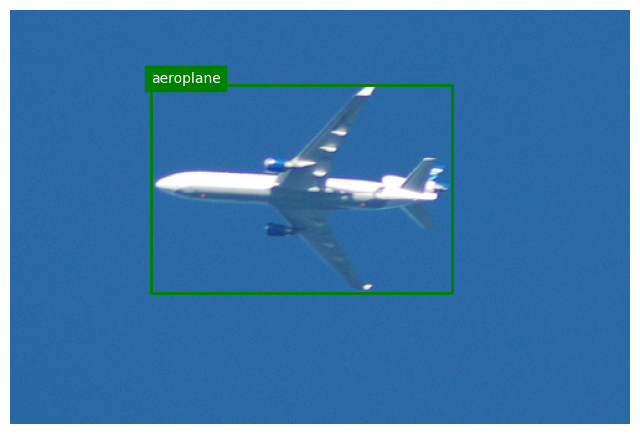

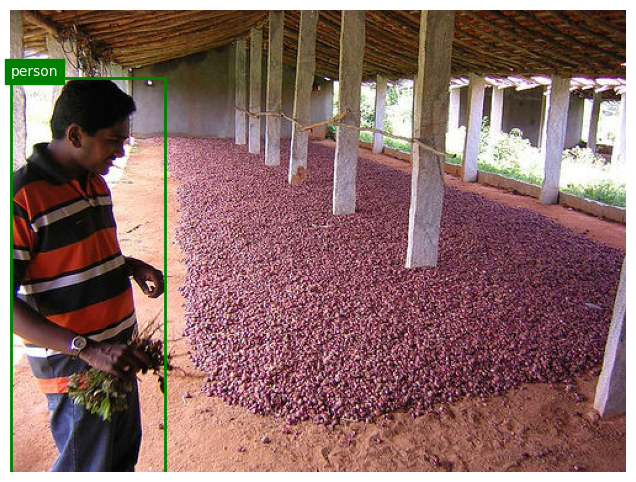

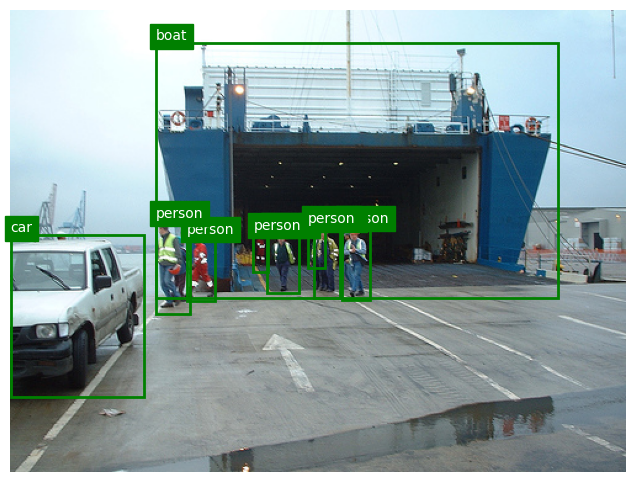

2026-08-24 18:46:52,657 - FasterRCNN_Pipeline - INFO - Dataset visualization completed


In [17]:
# Visualize dataset samples
print("📸 Visualizing dataset samples...")
try:
    visualize_dataset_samples(dataset_train, num_samples=3)
    logger.info("Dataset visualization completed")
except Exception as e:
    logger.error(f"Dataset visualization failed: {e}")
    print(f"⚠️ Dataset visualization failed: {e}")

## 13. Model Setup

In [18]:
# Create model
logger.info("Creating Faster R-CNN model...")

try:
    model = create_fasterrcnn_model(num_classes=len(VOC_CLASSES), pretrained=True)
    model = model.to(CONFIG['device'])
    
    # Setup optimizer and scheduler
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params,
        lr=CONFIG['learning_rate'],
        momentum=CONFIG['momentum'],
        weight_decay=CONFIG['weight_decay']
    )
    
    # Learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=3,
        gamma=0.1
    )
    
    # Calculate model size
    model_size = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 * 1024)
    training_metrics['model_size_mb'] = model_size
    
    print(f"✅ Model created successfully!")
    print(f"   Model: Faster R-CNN with ResNet50 backbone")
    print(f"   Device: {CONFIG['device']}")
    print(f"   Parameters: {training_metrics['total_parameters']:,}")
    print(f"   Model size: {model_size:.1f} MB")
    print(f"   Optimizer: SGD (lr={CONFIG['learning_rate']}, momentum={CONFIG['momentum']})")
    
    logger.info(f"Model setup completed - Device: {CONFIG['device']}, Size: {model_size:.1f}MB")
    
except Exception as e:
    logger.error(f"Failed to create model: {e}")
    print(f"❌ Failed to create model: {e}")

2026-08-24 18:46:52,666 - FasterRCNN_Pipeline - INFO - Creating Faster R-CNN model...
2026-08-24 18:46:52,669 - FasterRCNN_Pipeline - INFO - Creating Faster R-CNN model with 20 classes (pretrained=True)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 213MB/s] 
2026-08-24 18:46:54,288 - FasterRCNN_Pipeline - INFO - Model created successfully
2026-08-24 18:46:54,289 - FasterRCNN_Pipeline - INFO - Total parameters: 41,396,536
2026-08-24 18:46:54,289 - FasterRCNN_Pipeline - INFO - Trainable parameters: 41,174,136
2026-08-24 18:46:54,601 - FasterRCNN_Pipeline - INFO - Model setup completed - Device: cuda, Size: 157.9MB


✅ Model created successfully!
   Model: Faster R-CNN with ResNet50 backbone
   Device: cuda
   Parameters: 41,396,536
   Model size: 157.9 MB
   Optimizer: SGD (lr=0.005, momentum=0.9)


## 14. Training Loop

Training Progress Update - Epoch 5/5


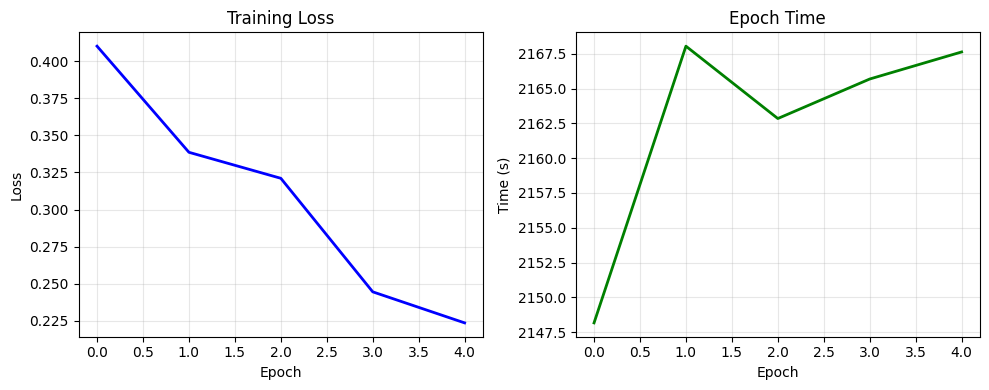

2026-08-24 21:47:16,062 - FasterRCNN_Pipeline - INFO - Training completed successfully in 3:00:21.444490
2026-08-24 21:47:16,063 - FasterRCNN_Pipeline - INFO - Final loss: 0.2237



🎉 Training completed successfully!
   Total time: 3:00:21.444490
   Final loss: 0.2237
   Best loss: 0.2237


In [19]:
# Training loop with enhanced monitoring
logger.info("Starting training...")
training_metrics['start_time'] = datetime.now()

print(f"🚀 Starting Faster R-CNN training...")
print(f"   Epochs: {CONFIG['num_epochs']}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Learning rate: {CONFIG['learning_rate']}")
print(f"   Device: {CONFIG['device']}")

best_loss = float('inf')

# Check for existing checkpoint
ckpt_path = f"{CONFIG['output_dir']}/models/checkpoint_latest.pth"
start_epoch = 0

if os.path.exists(ckpt_path):
    try:
        ckpt = torch.load(ckpt_path, map_location=CONFIG['device'])
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        lr_scheduler.load_state_dict(ckpt['lr_scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_loss = ckpt.get('loss', float('inf'))
        print(f"📂 Resuming from epoch {start_epoch + 1}")
        logger.info(f"Resuming training from epoch {start_epoch + 1}")
    except Exception as e:
        logger.warning(f"Failed to load checkpoint: {e}")
        print(f"⚠️ Failed to load checkpoint, starting from scratch")

try:
    for epoch in range(start_epoch, CONFIG['num_epochs']):
        logger.info(f"Starting epoch {epoch + 1}/{CONFIG['num_epochs']}")
        print(f"\n📊 Epoch {epoch + 1}/{CONFIG['num_epochs']}")
        
        # Train for one epoch
        epoch_loss = train_one_epoch(model, optimizer, train_loader, CONFIG['device'], epoch)
        lr_scheduler.step()
        
        # Update learning rate tracking
        current_lr = optimizer.param_groups[0]['lr']
        training_metrics['learning_rates'].append(current_lr)
        
        # Save checkpoint
        if CONFIG['save_checkpoints'] and (epoch + 1) % CONFIG['checkpoint_every'] == 0:
            checkpoint_path = f"{CONFIG['output_dir']}/models/fasterrcnn_epoch_{epoch + 1}.pth"
            is_best = epoch_loss < best_loss
            if is_best:
                best_loss = epoch_loss
            
            save_checkpoint(model, optimizer, lr_scheduler, epoch + 1, epoch_loss, checkpoint_path, is_best)
            
            # Also save as latest checkpoint
            save_checkpoint(model, optimizer, lr_scheduler, epoch + 1, epoch_loss, ckpt_path)
        
        # Print epoch summary
        print(f"   ✅ Epoch {epoch + 1} completed")
        print(f"   📉 Loss: {epoch_loss:.4f}")
        print(f"   ⏱️  Time: {training_metrics['epoch_times'][-1]:.1f}s")
        print(f"   📚 Learning Rate: {current_lr:.6f}")
        
        # Early visualization of training progress
        if (epoch + 1) % 2 == 0 or epoch == CONFIG['num_epochs'] - 1:
            clear_output(wait=True)
            print(f"Training Progress Update - Epoch {epoch + 1}/{CONFIG['num_epochs']}")
            if len(training_metrics['train_losses']) > 1:
                plt.figure(figsize=(10, 4))
                plt.subplot(1, 2, 1)
                plt.plot(training_metrics['train_losses'], 'b-', linewidth=2)
                plt.title('Training Loss')
                plt.xlabel('Epoch')
                plt.ylabel('Loss')
                plt.grid(True, alpha=0.3)
                
                plt.subplot(1, 2, 2)
                plt.plot(training_metrics['epoch_times'], 'g-', linewidth=2)
                plt.title('Epoch Time')
                plt.xlabel('Epoch')
                plt.ylabel('Time (s)')
                plt.grid(True, alpha=0.3)
                
                plt.tight_layout()
                plt.show()
    
    training_metrics['end_time'] = datetime.now()
    total_training_time = training_metrics['end_time'] - training_metrics['start_time']
    
    print(f"\n🎉 Training completed successfully!")
    print(f"   Total time: {total_training_time}")
    print(f"   Final loss: {training_metrics['train_losses'][-1]:.4f}")
    print(f"   Best loss: {best_loss:.4f}")
    
    logger.info(f"Training completed successfully in {total_training_time}")
    logger.info(f"Final loss: {training_metrics['train_losses'][-1]:.4f}")
    
except Exception as e:
    training_metrics['end_time'] = datetime.now()
    logger.error(f"Training failed: {e}")
    print(f"❌ Training failed: {e}")
    raise e

## 15. Model Evaluation

In [20]:
# Evaluate the trained model
logger.info("Starting model evaluation...")

print(f"🔍 Evaluating trained model...")

try:
    # Load ground truth COCO for evaluation
    coco_gt = COCO(CONFIG['coco_file'])
    
    # Fix missing fields in COCO GT (required by pycocotools)
    if 'info' not in coco_gt.dataset:
        coco_gt.dataset['info'] = {}
    if 'licenses' not in coco_gt.dataset:
        coco_gt.dataset['licenses'] = []
    
    # Evaluate on validation set
    eval_metrics = evaluate_model(model, val_loader, CONFIG['device'], coco_gt)
    
    if eval_metrics:
        training_metrics['final_metrics'] = eval_metrics
        training_metrics['best_map'] = eval_metrics.get('mAP_0.5', 0.0)
        
        print(f"\n📊 Evaluation Results:")
        print(f"   mAP@0.5-0.95: {eval_metrics.get('mAP_0.5_0.95', 0):.4f}")
        print(f"   mAP@0.5: {eval_metrics.get('mAP_0.5', 0):.4f}")
        print(f"   mAP@0.75: {eval_metrics.get('mAP_0.75', 0):.4f}")
        print(f"   AR@100: {eval_metrics.get('AR_100', 0):.4f}")
        
        logger.info(f"Evaluation completed - mAP@0.5: {eval_metrics.get('mAP_0.5', 0):.4f}")
    else:
        print(f"⚠️  Evaluation completed but no metrics generated")
        logger.warning("Evaluation completed but no metrics generated")
        
except Exception as e:
    logger.error(f"Evaluation failed: {e}")
    print(f"❌ Evaluation failed: {e}")

2026-08-24 21:47:16,073 - FasterRCNN_Pipeline - INFO - Starting model evaluation...


🔍 Evaluating trained model...
loading annotations into memory...
Done (t=0.11s)
creating index...


2026-08-24 21:47:16,453 - FasterRCNN_Pipeline - INFO - Starting model evaluation...


index created!


2026-08-24 21:47:16,585 - FasterRCNN_Pipeline - INFO - Evaluation batch 1/5823
2026-08-24 21:47:22,669 - FasterRCNN_Pipeline - INFO - Evaluation batch 51/5823
2026-08-24 21:47:29,033 - FasterRCNN_Pipeline - INFO - Evaluation batch 101/5823
2026-08-24 21:47:35,224 - FasterRCNN_Pipeline - INFO - Evaluation batch 151/5823
2026-08-24 21:47:41,543 - FasterRCNN_Pipeline - INFO - Evaluation batch 201/5823
2026-08-24 21:47:47,785 - FasterRCNN_Pipeline - INFO - Evaluation batch 251/5823
2026-08-24 21:47:54,059 - FasterRCNN_Pipeline - INFO - Evaluation batch 301/5823
2026-08-24 21:48:00,181 - FasterRCNN_Pipeline - INFO - Evaluation batch 351/5823
2026-08-24 21:48:06,420 - FasterRCNN_Pipeline - INFO - Evaluation batch 401/5823
2026-08-24 21:48:12,627 - FasterRCNN_Pipeline - INFO - Evaluation batch 451/5823
2026-08-24 21:48:18,692 - FasterRCNN_Pipeline - INFO - Evaluation batch 501/5823
2026-08-24 21:48:24,899 - FasterRCNN_Pipeline - INFO - Evaluation batch 551/5823
2026-08-24 21:48:31,102 - Faste

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


2026-08-24 21:59:20,463 - FasterRCNN_Pipeline - ERROR - COCO evaluation failed: Results do not correspond to current coco set
2026-08-24 21:59:20,508 - FasterRCNN_Pipeline - WARNING - Evaluation completed but no metrics generated


Loading and preparing results...
⚠️  Evaluation completed but no metrics generated


## 16. Inference Speed Benchmarking

In [21]:
# Benchmark inference speed using the shared timing harness (P0:
# benchmark_common.speed_bench). Images are pre-loaded into memory before
# timing starts, so disk I/O is excluded from the reported numbers -- unlike
# the previous DataLoader-based aggregate FPS, which bundled data loading
# into "inference" time.
# Note: torchvision's detection heads apply NMS internally as part of the
# forward pass in eval mode, so "postprocessing" here is the confidence-
# threshold filter this notebook already applies to raw model output elsewhere.
logger.info("Benchmarking inference speed...")

try:
    import glob
    from torchvision.transforms.functional import to_tensor

    _bench_image_paths = sorted(glob.glob(f"{CONFIG['voc_root']}/JPEGImages/*.jpg"))[:protocol.TIMED_ITERS]
    _bench_images = [Image.open(p).convert('RGB') for p in _bench_image_paths]

    def _fr_preprocess(pil_img):
        return to_tensor(pil_img).to(CONFIG['device'])

    def _fr_infer(tensor_img):
        with torch.no_grad():
            return model([tensor_img])

    def _fr_postprocess(raw_output):
        scores = raw_output[0]['scores']
        return scores[scores >= protocol.CONF_THRESHOLD]

    speed_metrics = speed_bench.benchmark_speed(
        _fr_preprocess, _fr_infer, _fr_postprocess, _bench_images, CONFIG['device'],
        warmup_iters=protocol.WARMUP_ITERS, timed_iters=protocol.TIMED_ITERS
    )
    fps = speed_metrics['fps_latency']

    all_metrics = {
        "mAP_0.5_0.95": training_metrics['final_metrics'].get('mAP_0.5_0.95', 0.0),
        "mAP_0.5": training_metrics['final_metrics'].get('mAP_0.5', 0.0),
        "mAP_0.75": training_metrics['final_metrics'].get('mAP_0.75', 0.0),
        "precision": training_metrics['final_metrics'].get('precision', 0.0),
        "recall": training_metrics['final_metrics'].get('recall', 0.0),
        "f1": training_metrics['final_metrics'].get('f1', 0.0),
        "FPS": fps,
        "speed_metrics": speed_metrics
    }

    metrics_file = f"{CONFIG['output_dir']}/predictions/fasterrcnn_metrics.json"
    with open(metrics_file, 'w') as f:
        json.dump(all_metrics, f, indent=2)

    print(f"\n⚡ Performance Summary:")
    print(f"   Preprocessing: {speed_metrics['preprocessing_ms']:.2f} ms")
    print(f"   Inference: {speed_metrics['inference_ms']:.2f} ms")
    print(f"   Postprocessing: {speed_metrics['postprocessing_ms']:.2f} ms")
    print(f"   Latency FPS: {fps:.1f} | Throughput FPS: {speed_metrics['fps_throughput']:.1f}")
    print(f"   Metrics saved to: {metrics_file}")

    logger.info(f"Speed benchmarking completed - Latency FPS: {fps:.1f}")

except Exception as e:
    logger.error(f"Speed benchmarking failed: {e}")
    print(f"⚠️ Speed benchmarking failed: {e}")


2026-08-24 21:59:20,520 - FasterRCNN_Pipeline - INFO - Benchmarking inference speed...
2026-08-24 21:59:35,759 - FasterRCNN_Pipeline - INFO - Speed benchmarking completed - Latency FPS: 8.1



⚡ Performance Summary:
   Preprocessing: 1.90 ms
   Inference: 121.28 ms
   Postprocessing: 0.14 ms
   Latency FPS: 8.1 | Throughput FPS: 8.1
   Metrics saved to: /kaggle/working/fasterrcnn_outputs/predictions/fasterrcnn_metrics.json


## 17. Training Progress Visualization

2026-08-24 22:13:23,325 - FasterRCNN_Pipeline - INFO - Creating training progress visualization...
2026-08-24 22:13:24,898 - FasterRCNN_Pipeline - INFO - Training progress plot saved to /kaggle/working/fasterrcnn_outputs/visualizations/training_progress.png


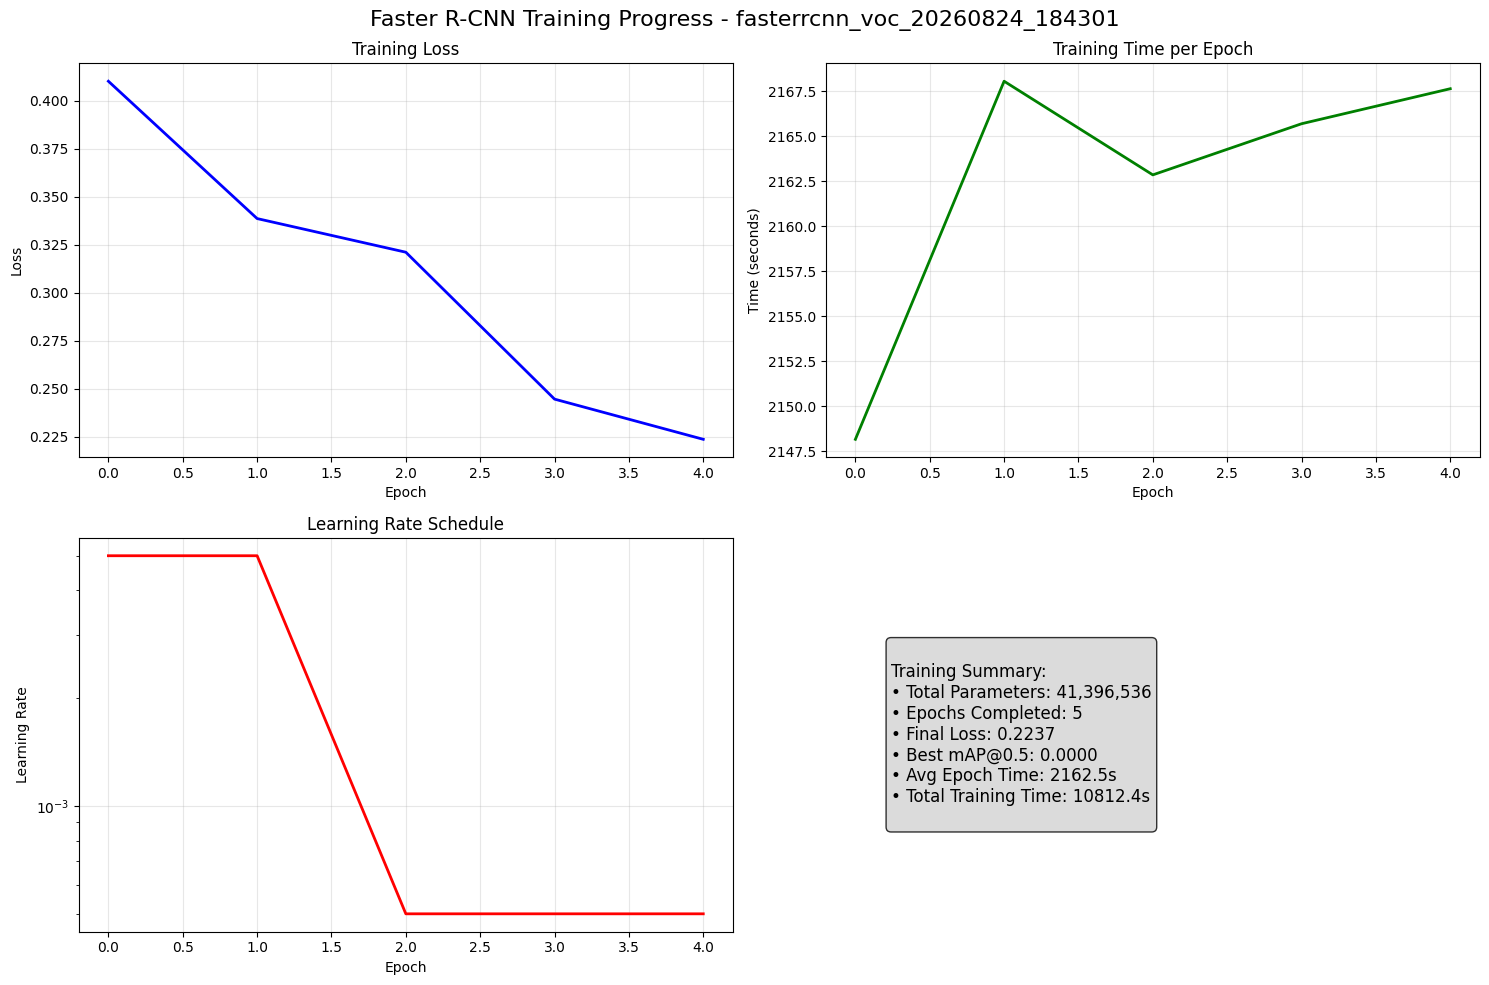

✅ Training visualization saved to /kaggle/working/fasterrcnn_outputs/visualizations/training_progress.png


In [27]:
# Create comprehensive training visualization
if CONFIG['save_visualizations']:
    logger.info("Creating training progress visualization...")
    
    viz_path = f"{CONFIG['output_dir']}/visualizations/training_progress.png"
    visualize_training_progress(training_metrics, viz_path)
    
    print(f"✅ Training visualization saved to {viz_path}")

## 18. Sample Predictions Visualization

2026-08-24 22:09:12,914 - FasterRCNN_Pipeline - INFO - Creating sample predictions visualization...
2026-08-24 22:09:18,039 - FasterRCNN_Pipeline - INFO - Prediction visualization saved to /kaggle/working/fasterrcnn_outputs/visualizations/sample_predictions.png


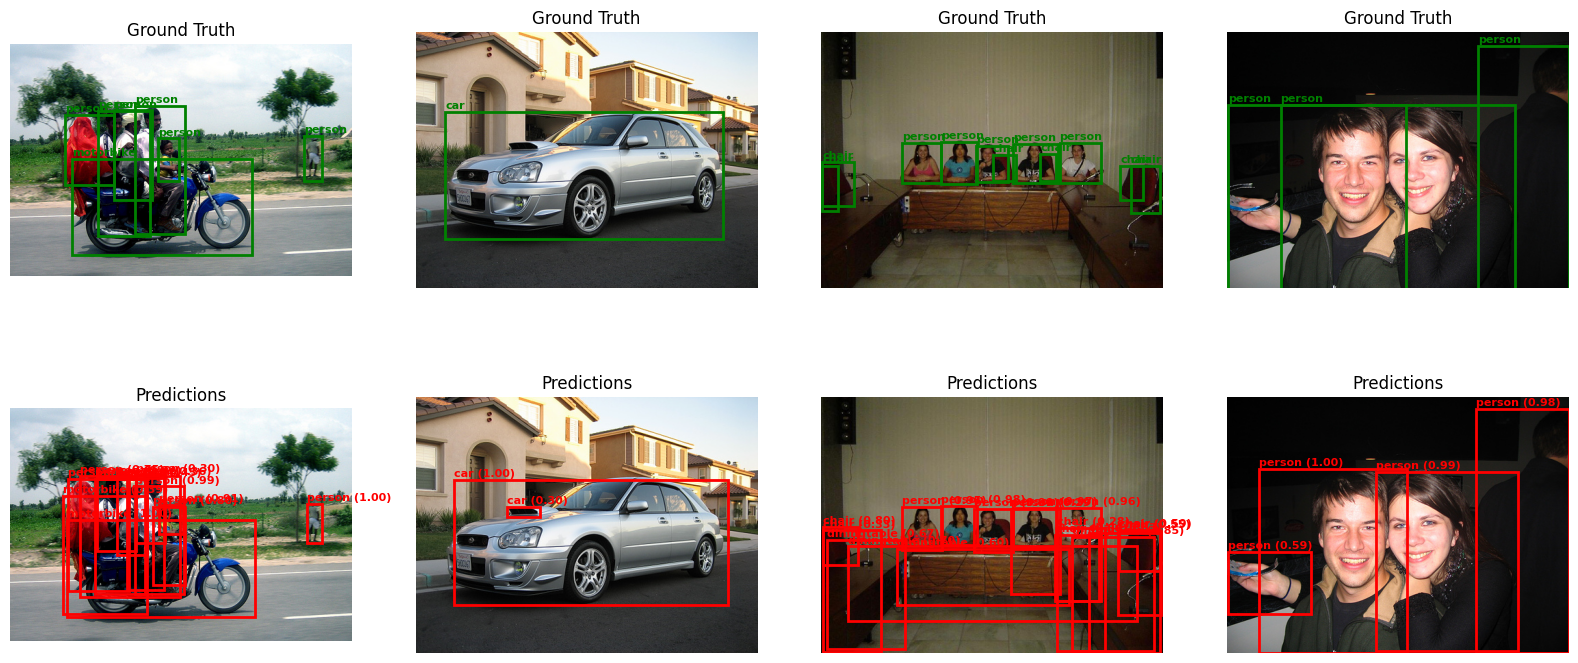

✅ Sample predictions visualization saved to /kaggle/working/fasterrcnn_outputs/visualizations/sample_predictions.png


In [25]:
# Visualize sample predictions
if CONFIG['save_visualizations']:
    logger.info("Creating sample predictions visualization...")
    
    pred_viz_path = f"{CONFIG['output_dir']}/visualizations/sample_predictions.png"
    visualize_predictions(model, dataset_val, CONFIG['device'], num_images=4, save_path=pred_viz_path)
    
    print(f"✅ Sample predictions visualization saved to {pred_viz_path}")

## 19. Comparison Images Testing

2026-08-24 22:13:33,678 - FasterRCNN_Pipeline - INFO - Testing on comparison images...
2026-08-24 22:13:33,680 - FasterRCNN_Pipeline - INFO - Testing on 20 comparison images...
2026-08-24 22:13:33,683 - FasterRCNN_Pipeline - INFO - Found 2 comparison images in dataset


🖼️  Testing on comparison images...
Loaded comparison manifest: /kaggle/working/object-detection-benchmarking-and-analysis/comparison_images.json -- 20/20 images


2026-08-24 22:13:36,873 - FasterRCNN_Pipeline - INFO - Comparison visualization saved to /kaggle/working/fasterrcnn_outputs/visualizations/comparison_predictions.png


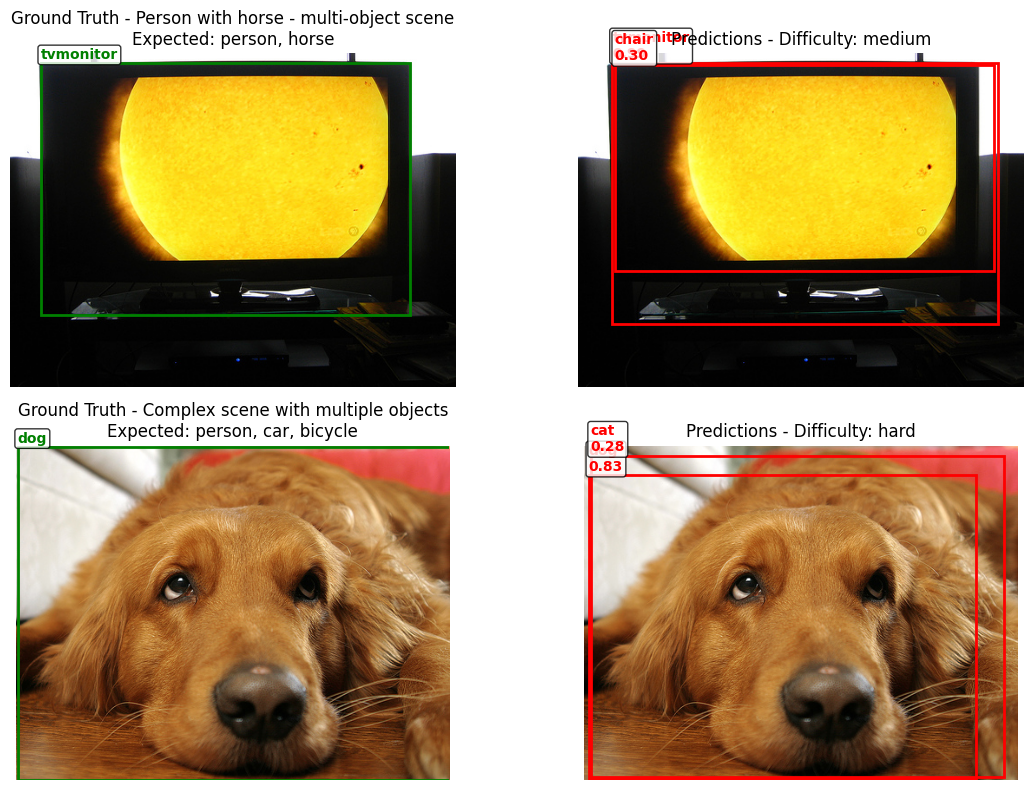

2026-08-24 22:13:37,311 - FasterRCNN_Pipeline - INFO - Comparison results saved to /kaggle/working/fasterrcnn_outputs/predictions/comparison_results.json
2026-08-24 22:13:37,314 - FasterRCNN_Pipeline - INFO - Comparison testing completed on 2 images



🎯 Comparison Images Results Summary:

📷 2008_000002.jpg (medium)
   Expected: person, horse
   Predicted: chair, tvmonitor
   Overlap: None
   Avg Confidence: 0.644

📷 2008_001430.jpg (hard)
   Expected: person, bicycle, car
   Predicted: dog, cat
   Overlap: None
   Avg Confidence: 0.554

✅ Comparison testing completed!
   Tested images: 2


In [28]:
# Test on comparison images (P0: benchmark_common.comparison -- fail-loud
# shared manifest, no silent fallback to a smaller default set)
if CONFIG['run_comparison_images']:
    logger.info("Testing on comparison images...")

    print(f"🖼️  Testing on comparison images...")

    comparison_manifest = comparison.load_comparison_manifest([
        '/kaggle/input/comparison-images/comparison_images.json',
        '/kaggle/working/comparison_images.json',
        './comparison_images.json',
        '../comparison_images.json',
        str(_REPO_ROOT / 'comparison_images.json'),
    ])

    try:
        comparison_results = test_comparison_images(model, dataset_val, CONFIG['device'], comparison_manifest)

        print(f"\n✅ Comparison testing completed!")
        print(f"   Tested images: {len(comparison_results)}")

        logger.info(f"Comparison testing completed on {len(comparison_results)} images")

    except Exception as e:
        logger.error(f"Comparison testing failed: {e}")
        print(f"❌ Comparison testing failed: {e}")
else:
    print(f"⏭️  Skipping comparison images testing (disabled in config)")


## 20. Final Report Generation

In [29]:
# Generate comprehensive final report
logger.info("Generating final report...")

final_report = {
    'experiment_info': {
        'name': CONFIG['experiment_name'],
        'timestamp': datetime.now().isoformat(),
        'model': 'Faster R-CNN',
        'backbone': 'ResNet50 + FPN',
        'dataset': 'Pascal VOC 2012',
        'device': CONFIG['device']
    },
    'environment_info': environment_info,
    'configuration': CONFIG,
    'training_metrics': training_metrics,
    'dataset_info': {
        'train_samples': len(dataset_train) if 'dataset_train' in locals() else 0,
        'val_samples': len(dataset_val) if 'dataset_val' in locals() else 0,
        'num_classes': len(VOC_CLASSES),
        'classes': VOC_CLASSES
    },
    'model_info': {
        'total_parameters': training_metrics['total_parameters'],
        'model_size_mb': training_metrics['model_size_mb'],
        'optimizer': 'SGD',
        'learning_rate': CONFIG['learning_rate'],
        'backbone': 'ResNet50 with Feature Pyramid Network'
    },
    'output_files': {
        'log_file': f"{CONFIG['output_dir']}/logs/{CONFIG['experiment_name']}.log",
        'final_model': f"{CONFIG['output_dir']}/models/fasterrcnn_epoch_{CONFIG['num_epochs']}.pth",
        'best_model': f"{CONFIG['output_dir']}/models/fasterrcnn_epoch_{CONFIG['num_epochs']}_best.pth",
        'predictions': f"{CONFIG['output_dir']}/predictions/fasterrcnn_predictions.json",
        'comparison_results': f"{CONFIG['output_dir']}/predictions/comparison_results.json",
        'metrics': f"{CONFIG['output_dir']}/predictions/fasterrcnn_metrics.json",
        'training_viz': f"{CONFIG['output_dir']}/visualizations/training_progress.png",
        'predictions_viz': f"{CONFIG['output_dir']}/visualizations/sample_predictions.png",
        'comparison_viz': f"{CONFIG['output_dir']}/visualizations/comparison_predictions.png"
    }
}

# Save final report
report_file = f"{CONFIG['output_dir']}/{CONFIG['experiment_name']}_final_report.json"
with open(report_file, 'w') as f:
    json.dump(final_report, f, indent=2, default=str)

# Save final model
final_model_path = f"{CONFIG['output_dir']}/models/fasterrcnn_final.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'lr_scheduler_state_dict': lr_scheduler.state_dict(),
    'config': CONFIG,
    'training_metrics': training_metrics,
    'final_report': final_report
}, final_model_path)

print(f"\n🎉 Faster R-CNN Pipeline Completed Successfully!")
print(f"\n📋 Final Summary:")
print(f"   Experiment: {CONFIG['experiment_name']}")
print(f"   Device: {CONFIG['device']}")
print(f"   Training time: {training_metrics['end_time'] - training_metrics['start_time']}")
print(f"   Epochs completed: {len(training_metrics['train_losses'])}/{CONFIG['num_epochs']}")
print(f"   Final loss: {training_metrics['train_losses'][-1]:.4f}")
if training_metrics['best_map'] > 0:
    print(f"   Best mAP@0.5: {training_metrics['best_map']:.4f}")
print(f"   Model size: {training_metrics['model_size_mb']:.1f} MB")
print(f"   Parameters: {training_metrics['total_parameters']:,}")

print(f"\n📁 Output Files:")
print(f"   📊 Final report: {report_file}")
print(f"   🤖 Final model: {final_model_path}")
print(f"   📝 Training log: {log_file}")
print(f"   📈 Visualizations: {CONFIG['output_dir']}/visualizations/")
print(f"   🎯 Predictions: {CONFIG['output_dir']}/predictions/")

logger.info(f"Faster R-CNN pipeline completed successfully!")
logger.info(f"Final report saved to {report_file}")
logger.info(f"Final model saved to {final_model_path}")
logger.info("=== EXPERIMENT COMPLETED ===")

print(f"\n✨ All done! Check the output directory for all generated files.")
print(f"\n\u26a0\ufe0f  Kaggle sessions are ephemeral -- click 'Save Version' now, or download ")
print(f"   {CONFIG['output_dir']} manually, or these results will be lost when the session ends.")

2026-08-24 22:14:08,978 - FasterRCNN_Pipeline - INFO - Generating final report...
2026-08-24 22:14:09,499 - FasterRCNN_Pipeline - INFO - Faster R-CNN pipeline completed successfully!
2026-08-24 22:14:09,500 - FasterRCNN_Pipeline - INFO - Final report saved to /kaggle/working/fasterrcnn_outputs/fasterrcnn_voc_20260824_184301_final_report.json
2026-08-24 22:14:09,500 - FasterRCNN_Pipeline - INFO - Final model saved to /kaggle/working/fasterrcnn_outputs/models/fasterrcnn_final.pth
2026-08-24 22:14:09,501 - FasterRCNN_Pipeline - INFO - === EXPERIMENT COMPLETED ===



🎉 Faster R-CNN Pipeline Completed Successfully!

📋 Final Summary:
   Experiment: fasterrcnn_voc_20260824_184301
   Device: cuda
   Training time: 3:00:21.444490
   Epochs completed: 5/5
   Final loss: 0.2237
   Model size: 157.9 MB
   Parameters: 41,396,536

📁 Output Files:
   📊 Final report: /kaggle/working/fasterrcnn_outputs/fasterrcnn_voc_20260824_184301_final_report.json
   🤖 Final model: /kaggle/working/fasterrcnn_outputs/models/fasterrcnn_final.pth
   📝 Training log: /kaggle/working/fasterrcnn_outputs/logs/fasterrcnn_voc_20260824_184301.log
   📈 Visualizations: /kaggle/working/fasterrcnn_outputs/visualizations/
   🎯 Predictions: /kaggle/working/fasterrcnn_outputs/predictions/

✨ All done! Check the output directory for all generated files.

⚠️  Kaggle sessions are ephemeral -- click 'Save Version' now, or download 
   /kaggle/working/fasterrcnn_outputs manually, or these results will be lost when the session ends.
